# Load functions

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
from battery_analysis import *

In [2]:
results_dir = '100%SOC_25degC'

 # $\bf Monte\ Carlo\ Parameters$

In [7]:
monte_carlo_summary = pd.read_csv(f'{results_dir}/monte_carlo_parallel_summary.csv')

d:\anaconda3\envs\battery\lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\anaconda3\envs\battery\lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
d:\anaconda3\envs\battery\lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\anaconda3\envs\battery\lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
d:\anaconda3\envs\battery\lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\anaconda3\envs\battery\lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
d:\anaconda3\envs\battery\lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarn

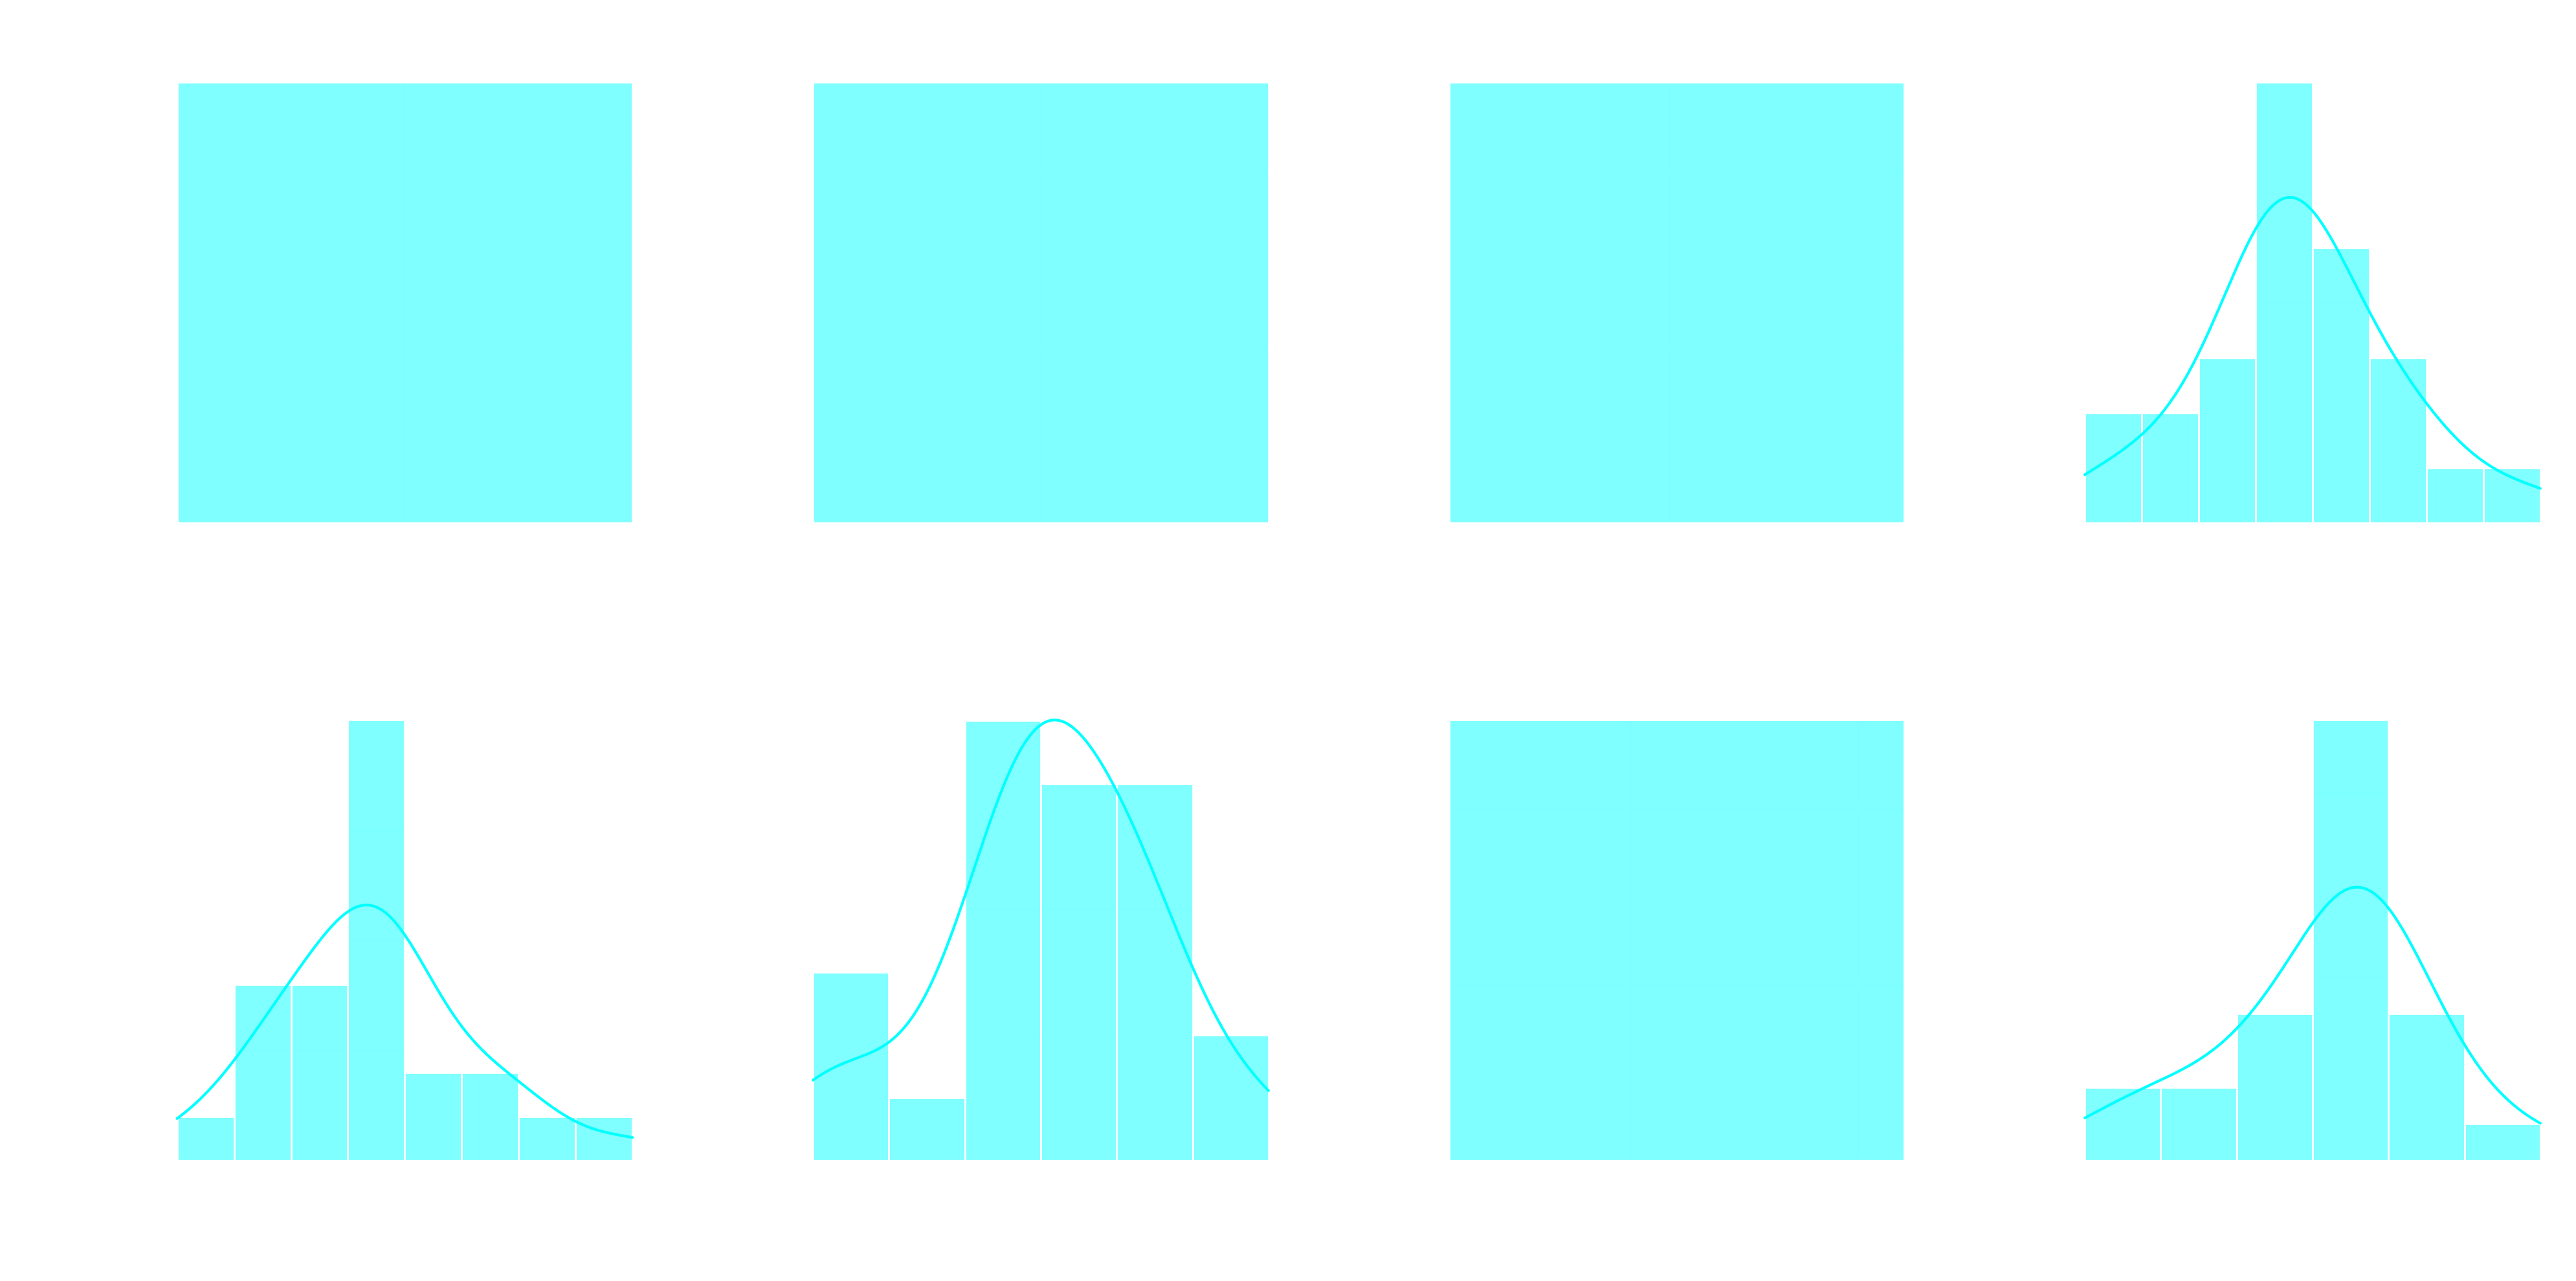

In [8]:
params = ['bR', 'cR', 'dR', 'aR', 'bC', 'cC', 'dC', 'aC']
y_col = 'Final_Capacity'

with sns.axes_style('darkgrid'):
    fig, axes = plt.subplots(2, 4, figsize=(20, 10), dpi=200)
    fig.patch.set_alpha(0.0)
    
    axes_flat = axes.flatten()
    
    for i, ax in enumerate(axes_flat):
        ax.patch.set_alpha(0.0)
        
        if i < len(params):
            param = params[i]
            
            # Calculate correlation
            corr = monte_carlo_summary[param].corr(monte_carlo_summary[y_col])
            
            # Plot histogram with KDE
            sns.histplot(data=monte_carlo_summary, x=param, kde=True, 
                        color='cyan', edgecolor='white', alpha=0.5, ax=ax)
            
            # Styling
            ax.set_title(rf'$\bf {param}$', color='white', fontsize=30)
            ax.set_xlabel(rf'$\bf {param}$', color='white', fontsize=30)
            ax.set_ylabel(rf'$\bf Count$', color='white', fontsize=30)
            
            ax.tick_params(colors='white', labelsize=25)
            ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

d:\anaconda3\envs\battery\lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\anaconda3\envs\battery\lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


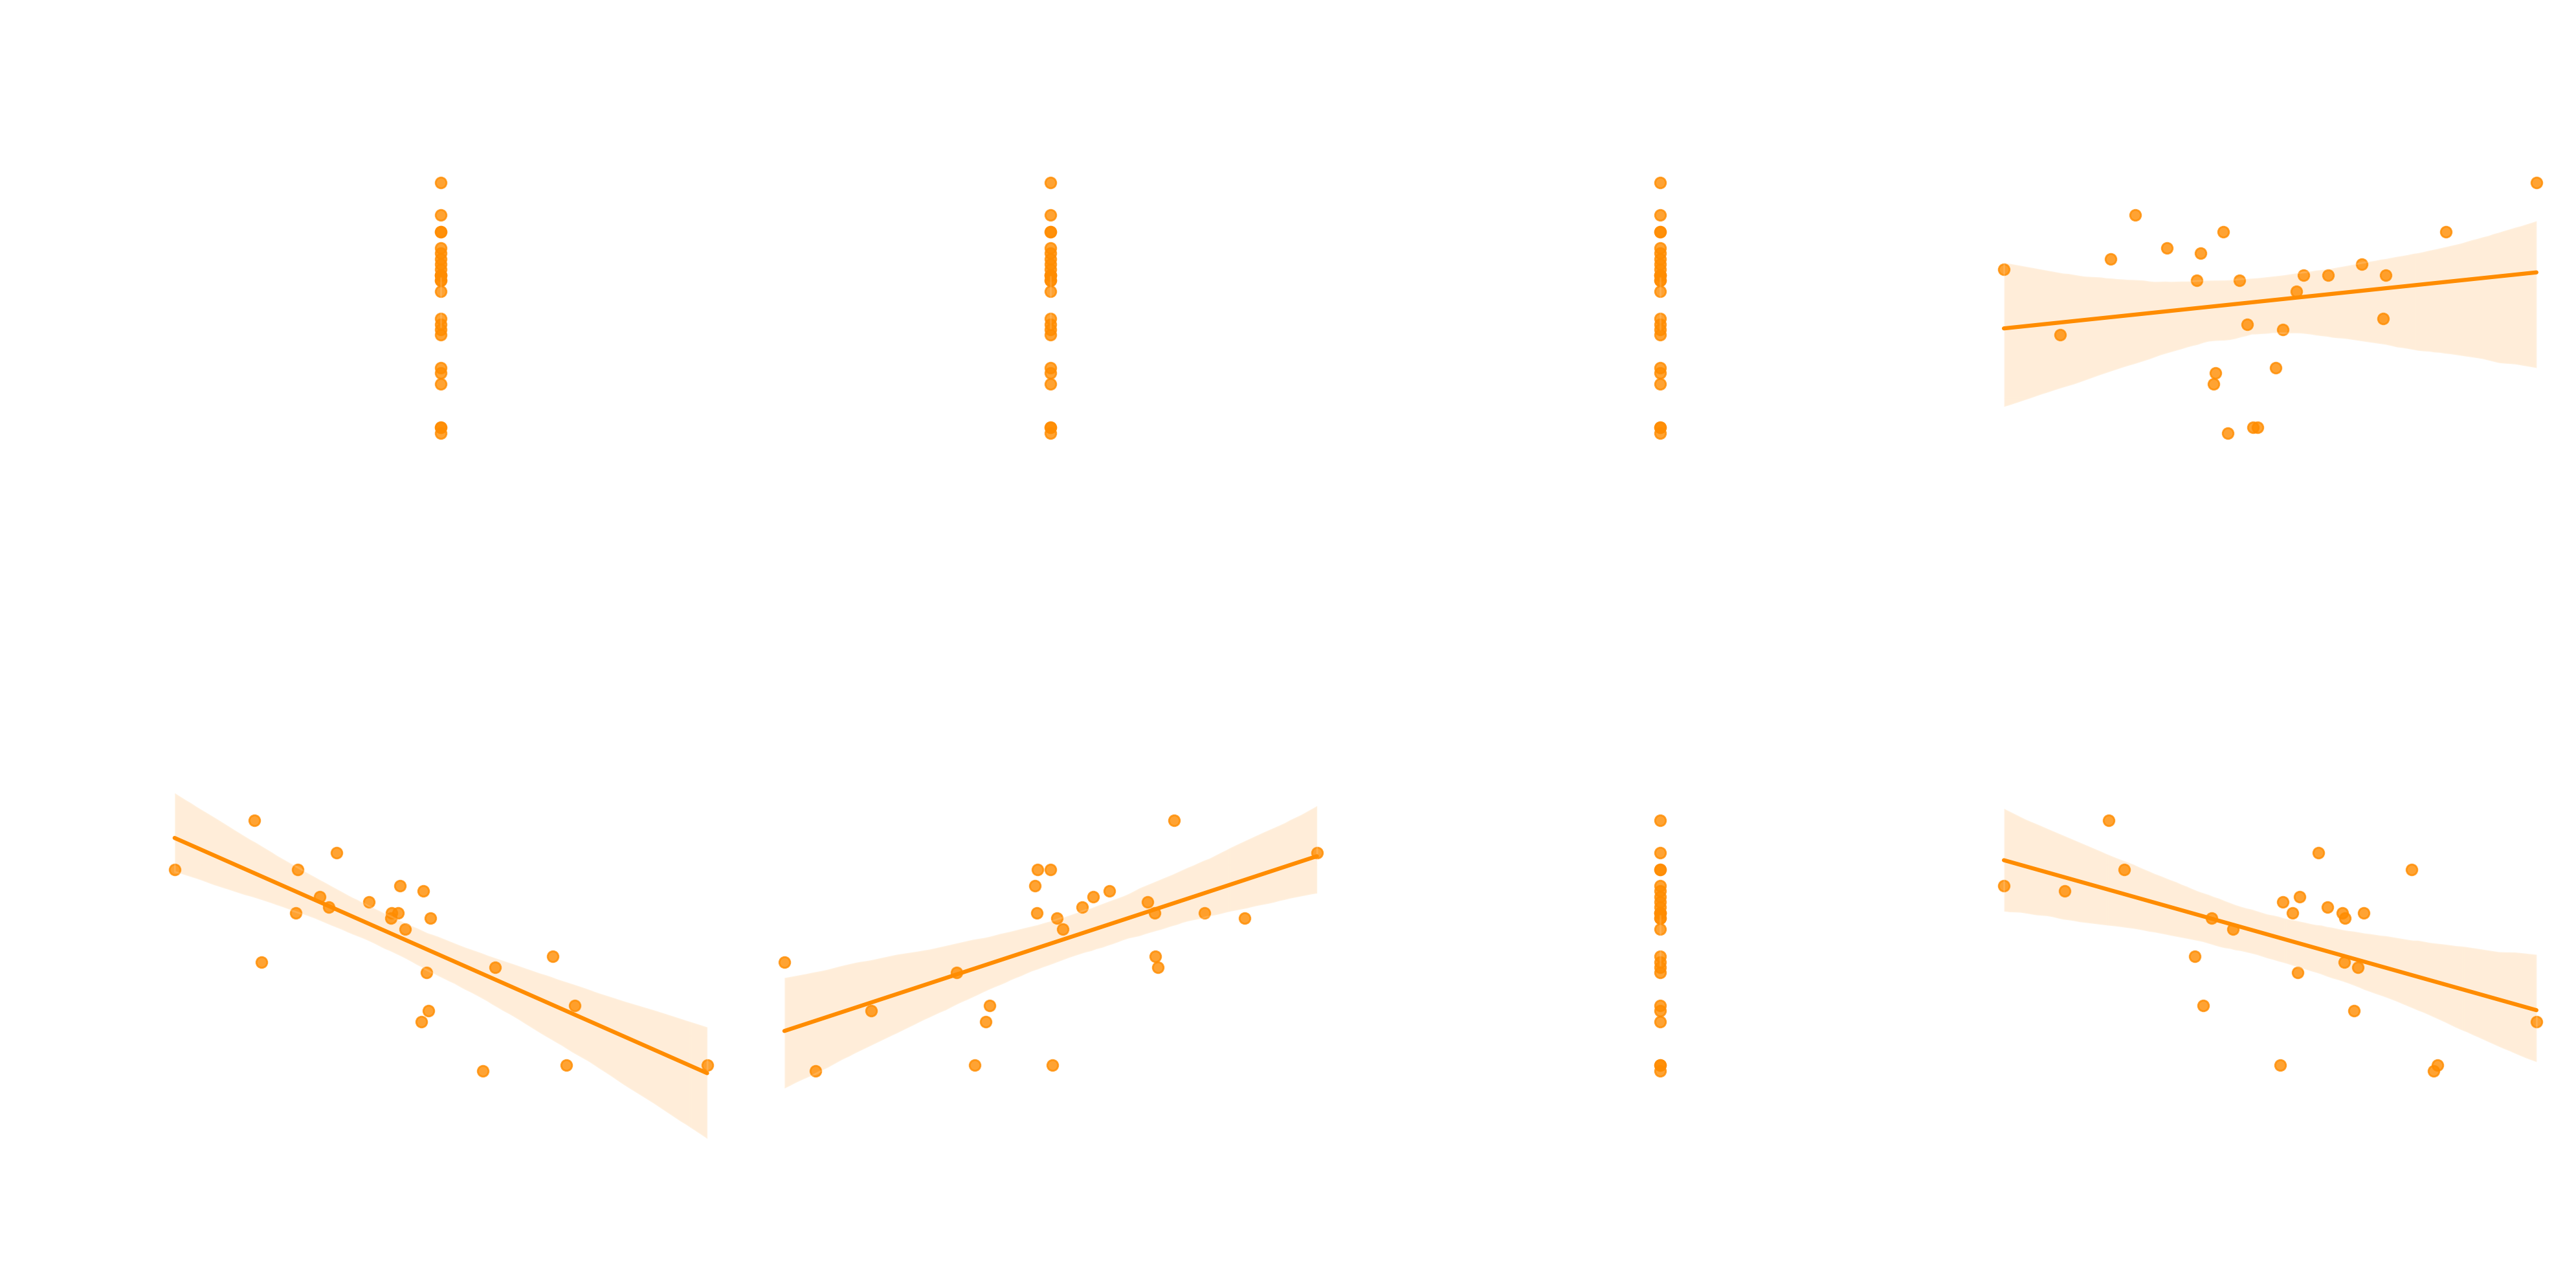

In [9]:
with sns.axes_style('darkgrid'):
    fig, axes = plt.subplots(2, 4, figsize=(20, 10), dpi=200, sharey=True)
    fig.patch.set_alpha(0.0)
    axes_flat = axes.flatten()
    
    for i, ax in enumerate(axes_flat):
        ax.patch.set_alpha(0.0)
        
        if i < len(params):
            param = params[i]
    
            # Calculate correlation
            corr = monte_carlo_summary[param].corr(monte_carlo_summary[y_col])
            
            # Plot histogram with KDE
            sns.regplot(data=monte_carlo_summary, x=param, y=y_col, 
                        color='darkorange',ax=ax)
            
            # Styling
            ax.set_title(rf'$\begin{{array}}{{c}} \bf Q_{{end}}\ v.s\ {param} \\ \bf (r={corr:.2f}) \end{{array}}$', 
                        color='white', fontsize=30, pad=30)
            ax.set_xlabel(rf'$\bf {param} (\%)$', color='white', fontsize=30)
            
            if i == 0:
                ax.set_ylabel(rf'$\bf Q_{{end}} (Ah)$', color='white', fontsize=30)
            else:
                ax.set_ylabel('')
            
            ax.patch.set_alpha(0.0)
            ax.tick_params(colors='white', labelsize=25)
            ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

 # $\bf 100\% SOC @ 25^{\circ} C$

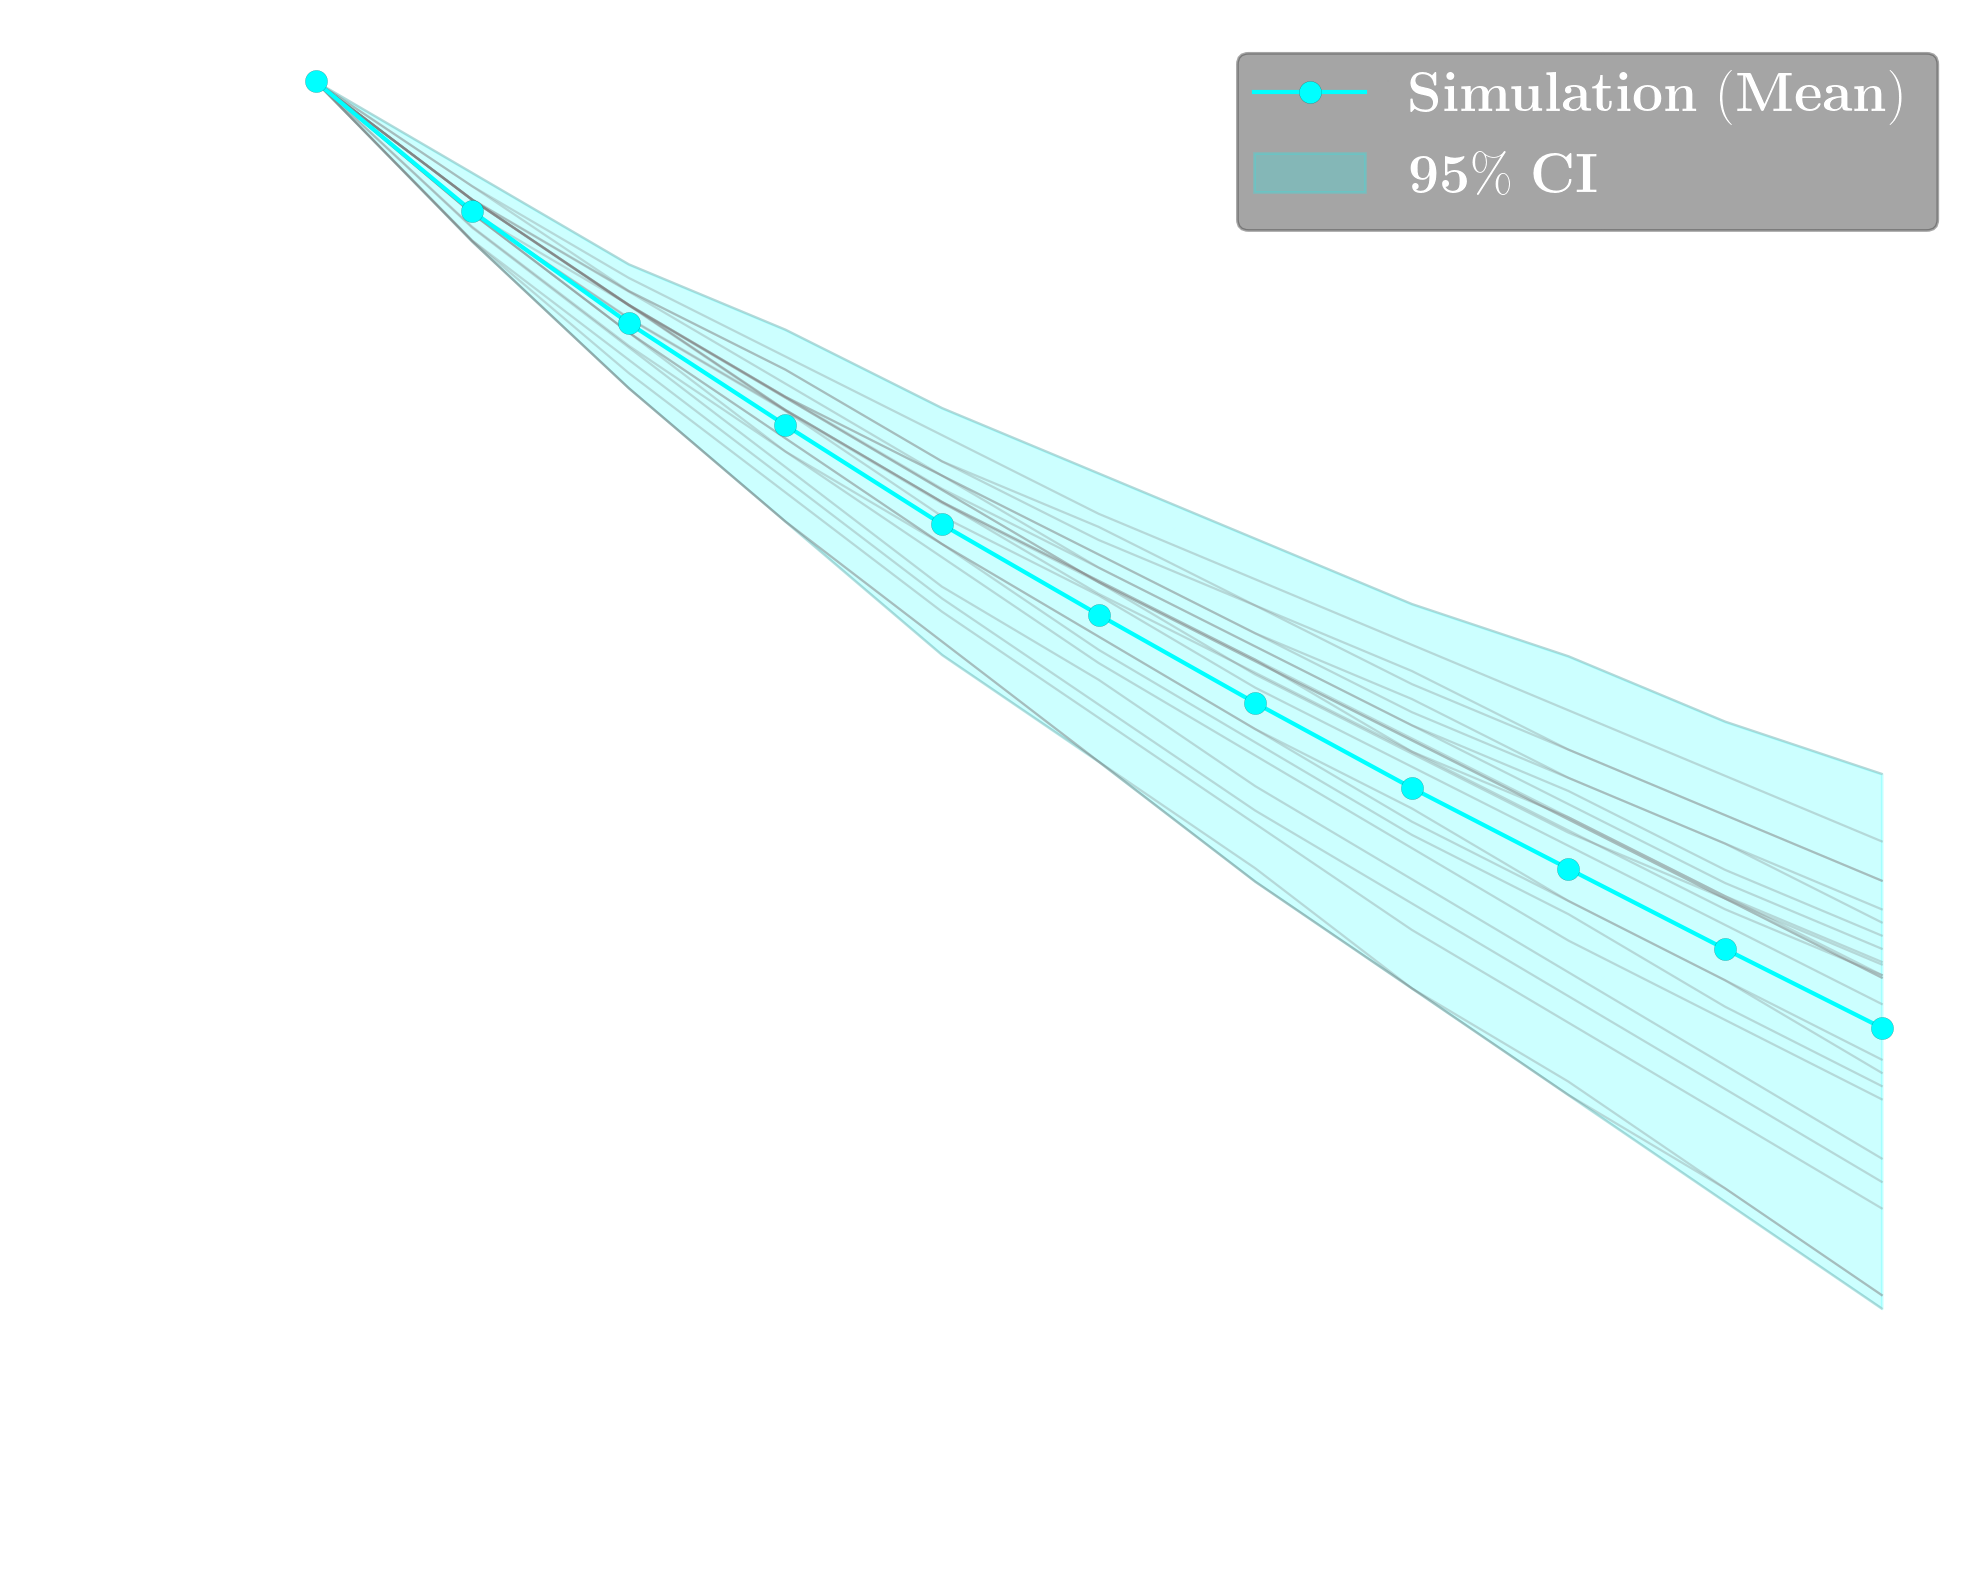

(<Figure size 2000x1600 with 1 Axes>,
 <Axes: xlabel='$\\bf Time\\ (days)$', ylabel='$\\bf Retention\\ (\\%)$'>)

In [11]:
lo, hi, retention_matfile = get_retention_matrix(f'{results_dir}/monte_carlo_parallel_results.mat', start_index=1)
retention_matrix = np.array(retention_matfile)
mean_ret = np.mean(retention_matrix, axis=0)
period   = 365
n_years = 11
sim_days = list(range(0, len(mean_ret) * period, period))
sim_yrs  = [d / 365 for d in sim_days]
t_years  = list(range(n_years))
plot_calendar_retention(
    simulation_days = sim_days,
    retention_matrix = retention_matrix,
    mean_retention = mean_ret,
    retention_lower = np.min(retention_matrix, axis=0),
    retention_upper = np.max(retention_matrix, axis=0),
)